Title: LEE_Results_Analysis.ipynb

Purpose: Look at the found LEE Events

Author: Onno Nennecke on 16.07.2025 Modified: 11.09.2025

Input data: 

- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

Output data:

- Plots: LEE_Event_yearly_distr, LEE_durations_comparison
    - These files lie here: /home/onennecke/Code/Figures/

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import os
import glob

from datetime import datetime

# Importing functions

### Read LEE data

In [2]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')


---

### General Count

In [3]:
print(sum(LEE_dat['duration']))
print(sum(LEE_7['duration']))
print(sum(LEE_14['duration']))
print(sum(LEE_vl['duration']))

print(sum(LEE_dat['duration'])/ sum(LEE_7['duration']))

18605
8008
3640
18605
2.323301698301698


In [4]:
LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1423.036821,1423.036821,0.0,1423.036821,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1437.904166,1437.904166,0.0,1437.904166,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1479.128472,1479.128472,0.0,1479.128472,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1469.444224,1469.444224,0.0,1469.444224,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1484.203439,1484.203439,0.0,1484.203439,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18600,2022-01-25,2022-01-25,2022-01-25,2579,2579,2579,1,1433.217750,1433.217750,0.0,1433.217750,18601,SMARD,SMARD_hist,2022,25
18601,2023-11-30,2023-11-30,2023-11-30,3253,3253,3253,1,1446.194500,1446.194500,0.0,1446.194500,18602,SMARD,SMARD_hist,2023,334
18602,2023-12-01,2023-12-01,2023-12-01,3254,3254,3254,1,1409.966000,1409.966000,0.0,1409.966000,18603,SMARD,SMARD_hist,2023,335
18603,2024-12-11,2024-12-11,2024-12-11,3629,3629,3629,1,1425.075500,1425.075500,0.0,1425.075500,18604,SMARD,SMARD_hist,2024,345


---

### Check doy distribution

In [5]:
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd')]


In [4]:
# # Function to create a list of dates from start_date to end_date from the LEE data
# def create_date_list(LEE_data):
#     """
#     Generates a list of date strings from the start_date to end_date
#     for each event in the LEE_data DataFrame.

#     Parameters:
#         LEE_data (pd.DataFrame): A DataFrame containing 'date_start' and 'date_end' columns.

#     Returns:
#         list: A list of date strings in 'YYYY-MM-DD' format.
#     """
#     date_list = []
#     for start, end in zip(LEE_data['date_start'], LEE_data['date_end']):
#         dates = pd.date_range(start=start, end=end, freq='D')
#         date_list.extend(d.strftime('%Y-%m-%d') for d in dates)
#     return date_list


In [6]:
# Precompute cumulative days at month start in a non-leap year
_NONLEAP_CUMDAYS = {1:   0, 2:  31, 3:  59, 4:  90, 5: 120, 6: 151, 7: 181, 8: 212, 9: 243, 10: 273, 11: 304, 12: 334}

def _md_to_doy(month: int, day: int) -> int:
    """
    Convert month/day in a non-leap year to day-of-year (1-365).
    """
    return _NONLEAP_CUMDAYS[month] + day

def create_doy_list(LEE_data: pd.DataFrame) -> list[int]:
    """
    For each row in LEE_data, take 'date_start' and 'date_end' strings (YYYY-MM-DD),
    compute their non-leap DOYs (1-365), and then return all DOYs in that interval
    (inclusive), wrapping across year-end if start > end.

    Parameters:
        LEE_data (pd.DataFrame): must contain 'date_start' and 'date_end' as YYYY-MM-DD.

    Returns:
        list[int]: flat list of DOYs (1-365) covering each event.
    """
    doy_list: list[int] = []

    for start_str, end_str in zip(LEE_data['date_start'], LEE_data['date_end']):
        # parse out month/day
        ms, ds = datetime.strptime(start_str, "%Y-%m-%d").month, datetime.strptime(start_str, "%Y-%m-%d").day
        me, de = datetime.strptime(end_str,   "%Y-%m-%d").month, datetime.strptime(end_str,   "%Y-%m-%d").day

        start_doy = _md_to_doy(ms, ds)
        end_doy   = _md_to_doy(me, de)

        if start_doy <= end_doy:
            interval = range(start_doy, end_doy + 1)
        else:
            # wrap across year boundary
            interval = list(range(start_doy, 366)) + list(range(1, end_doy + 1))

        doy_list.extend(interval)

    return doy_list


In [7]:
LEE_dat_dl = create_doy_list(LEE_dat)
LEE_vl_dl = create_doy_list(LEE_vl)
LEE_7_dl = create_doy_list(LEE_7)
LEE_14_dl = create_doy_list(LEE_14)

### Check the LEE days for each month

In [8]:
# Precomputed non-leap month start DOYs
_MONTH_STARTS = {1:   1, 2:  32, 3:  60, 4:  91, 5: 121, 6: 152, 7: 182, 8: 213, 9: 244, 10: 274, 11: 305, 12: 335}

def plot_oct_apr_centered(doy, title, ax=None, left_axis=True):
    """
    Plots a daily-DOY histogram for Oct1–Apr30, with winter (Nov–Apr)
    centered in the middle of the x-axis.

    Args:
        doy (iterable of int): List/array/Series of day-of-year values (1–365).
        ax (matplotlib.axes.Axes): Axes to plot into. If None, uses current axes.
        left_axis (bool): If True, show y-axis label/ticks; otherwise hide them.
    """
    if ax is None:
        ax = plt.gca()

    # 1) Shift winter by half-year so Nov–Apr appear centrally.
    # Use ((d-1)+182) % 365 + 1 to keep values in 1..365
    shifted = [((int(d) - 1) + 182) % 365 + 1 for d in doy]

    # 2) Count occurrences for each shifted day and ensure full day-range is present
    counts = pd.Series(shifted).value_counts().sort_index()

    # 3) Compute tick positions for Oct→Apr month starts (shifted consistently)
    months = [10, 11, 12, 1, 2, 3, 4, 5]
    ticks = []
    labels = []
    month_name = {10: "Oct", 11: "Nov", 12: "Dec", 1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May"}
    for m in months:
        raw_start = _MONTH_STARTS[m]
        pos = ((raw_start - 1) + 182) % 365 + 1
        ticks.append(pos)
        labels.append(month_name[m])

    min_tick, max_tick = min(ticks), max(ticks)

    # 4) Reindex counts to include any missing days (fill with zeros) across the plotting window
    full_index = np.arange(min_tick, max_tick + 1, dtype=int)
    counts_full = counts.reindex(full_index, fill_value=0)

    # 5) Plot on provided axes
    ax.bar(full_index, counts_full.values, width=1.0,  alpha=0.8)
    ax.set_xlim(min_tick - 0.5, max_tick + 0.5)
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_title(title, fontsize=14, weight='bold', loc='left')

    if left_axis:
        ax.set_ylabel("Count per Day", fontsize=12)
    else:
        # hide left tick labels to keep plot clean (works with sharey=True)
        ax.tick_params(labelleft=False)

    ax.grid(axis='y', linestyle='--', alpha=0.5)

In [9]:
doy = LEE_vl_dl
doy_series = pd.Series(doy)
most_common_doy = doy_series.value_counts().idxmax()
frequency = doy_series.value_counts().max()

print(f"Most common DOY: {most_common_doy}, Frequency: {frequency}")

Most common DOY: 21, Frequency: 203


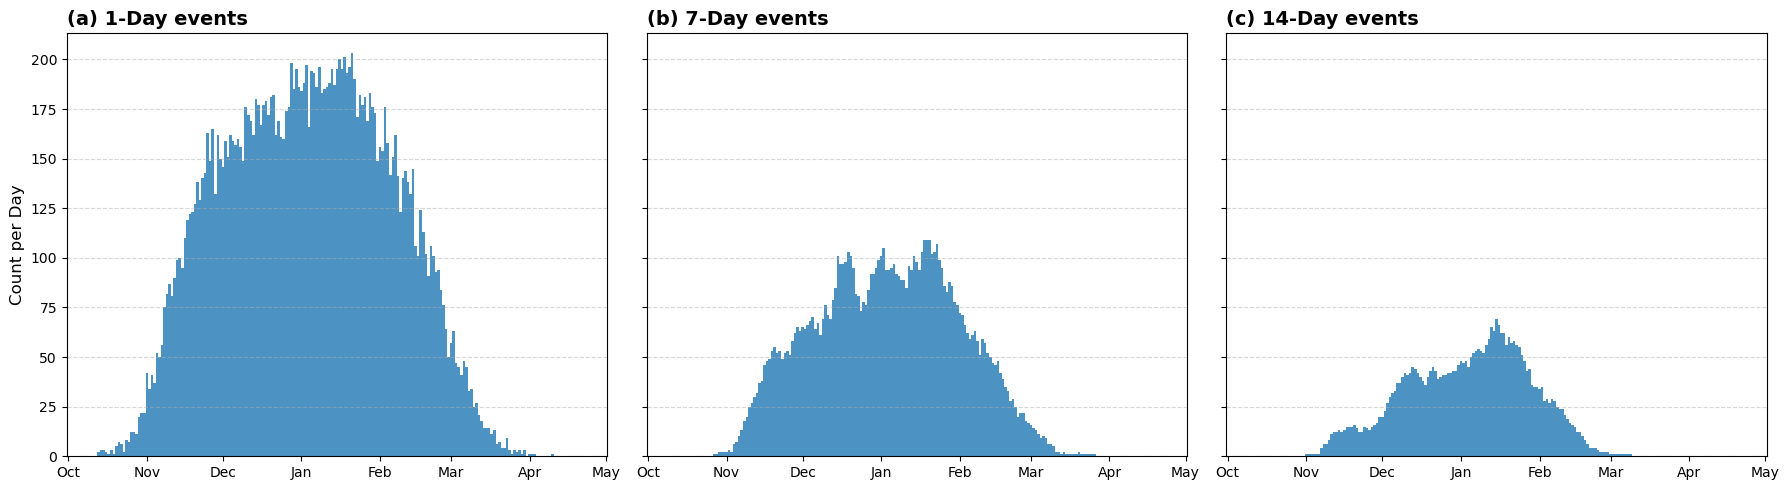

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

titles = ['(a) 1-Day events', '(b) 7-Day events', '(c) 14-Day events']
doy_lists = [LEE_vl_dl, LEE_7_dl, LEE_14_dl]  # keep these as your DOY lists (1..365)

for ax, title, doy in zip(axes, titles, doy_lists):
    plot_oct_apr_centered(doy, title, ax=ax, left_axis=(ax is axes[0]))

plt.tight_layout()
# Save the plot
plt.savefig('/home/onennecke/Code/Figures/LEE_Event_yearly_distr.png', bbox_inches='tight', dpi=300)
plt.show()


In [11]:
np.unique(doy)
shifted = [((int(d) - 1) + 182) % 365 + 1 for d in doy]
len(np.unique(shifted))

129

In [12]:
def oct_apr_centered(doy):
    # 1) Shift winter by half-year so Nov–Apr appear centrally.
    # Use ((d-1)+182) % 365 + 1 to keep values in 1..365
    shifted = [((int(d) - 1) + 182) % 365 + 1 for d in doy]

    # 2) Count occurrences for each shifted day and ensure full day-range is present
    counts = pd.Series(shifted).value_counts().sort_index()

    # 3) Compute tick positions for Oct→Apr month starts (shifted consistently)
    months = [10, 11, 12, 1, 2, 3, 4, 5]
    ticks = []
    labels = []
    month_name = {10: "Oct", 11: "Nov", 12: "Dec", 1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May"}
    for m in months:
        raw_start = _MONTH_STARTS[m]
        pos = ((raw_start - 1) + 182) % 365 + 1
        ticks.append(pos)
        labels.append(month_name[m])

    min_tick, max_tick = min(ticks), max(ticks)

    # 4) Reindex counts to include any missing days (fill with zeros) across the plotting window
    full_index = np.arange(min_tick, max_tick + 1, dtype=int)
    counts_full = counts.reindex(full_index, fill_value=0)

    return counts_full

In [13]:
LEE_vl_count = oct_apr_centered(LEE_vl_dl)
LEE_7_count = oct_apr_centered(LEE_7_dl)
LEE_14_count = oct_apr_centered(LEE_14_dl)


In [14]:
print([((int(274) - 1) + 182) % 365 + 1])
print([((int(121) - 1) + 182) % 365 + 1])
print([((int(203) - 1) + 182) % 365 + 1])
print([((int(20) - 1) + 182) % 365 + 1])

[91]
[303]
[20]
[202]


In [15]:
LEE_7_count

91     0
92     0
93     0
94     0
95     0
      ..
299    0
300    0
301    0
302    0
303    0
Name: count, Length: 213, dtype: int64

In [16]:
np.sort(LEE_vl_count)
lst = LEE_vl_count.nlargest(5).index.tolist()
for i in lst:
    print(i, ': ',[((int(i) - 1) + 182) % 365 + 1])

203 :  [20]
200 :  [17]
198 :  [15]
179 :  [361]
185 :  [2]


In [17]:
LEE_vl_count[40:60]
max(LEE_vl_count)
LEE_vl_count.idxmax()
LEE_vl_count[203]
LEE_vl_count[100:115]
# LEE_vl_count


191    183
192    185
193    186
194    188
195    195
196    187
197    195
198    200
199    195
200    201
201    193
202    196
203    203
204    190
205    171
Name: count, dtype: int64

In [18]:
LEE_vl_count.idxmax()
print([((int(LEE_vl_count.idxmax()) - 1) + 182) % 365 + 1])
print([((int(LEE_7_count.idxmax()) - 1) + 182) % 365 + 1])
print([((int(LEE_14_count.idxmax()) - 1) + 182) % 365 + 1])

[20]
[17]
[14]


In [19]:
LEE_14_count

91     0
92     0
93     0
94     0
95     0
      ..
299    0
300    0
301    0
302    0
303    0
Name: count, Length: 213, dtype: int64

In [20]:
LEE_14_dl_shifted = [(((int(i) - 1) + 182) % 365 + 1) for i in LEE_14_dl]
LEE_7_dl_shifted = [(((int(i) - 1) + 182) % 365 + 1) for i in LEE_7_dl]
LEE_dat_dl_shifted = [(((int(i) - 1) + 182) % 365 + 1) for i in LEE_dat_dl]


In [21]:
print(np.mean(LEE_14_dl_shifted))
print(np.median(LEE_14_dl_shifted))

185.97470817120623
188.5


In [23]:
from scipy import stats
import statsmodels.api as sm

# suppose `counts` is the array of daily counts for the 1-day events
# e.g. counts = np.array([...])
counts = np.array(tst)
# 1) Q-Q plot
sm.qqplot(counts, line='s')
plt.title('Q-Q plot against normal')
plt.show()

# 2) Normality tests
w, p_shapiro = stats.shapiro(counts)           # Shapiro-Wilk
k2, p_dagostino = stats.normaltest(counts)    # D'Agostino
ad_result = stats.anderson(counts, dist='norm')  # Anderson-Darling

print('Shapiro p=', p_shapiro)
print('D\'Agostino p=', p_dagostino)
print('Anderson statistic=', ad_result.statistic, 'critical=', ad_result.critical_values)


NameError: name 'tst' is not defined

In [22]:
data = np.array(LEE_14_dl_shifted)

# sample skewness (bias-corrected)
skew_corrected = stats.skew(data, bias=False)

# raw (uncorrected) moment skewness
skew_raw = stats.skew(data, bias=True)

print("skew (bias-corrected) =", skew_corrected)
print("skew (raw) =", skew_raw)

NameError: name 'stats' is not defined

### Check how the LEE Days are distributed over the modells

In [24]:
# Add number of runs to the DataFrame
Nr_of_runs = LEE_vl.groupby('ESM')['ESM_run'].nunique()
LEE_vl['Nr_of_runs'] = LEE_vl['ESM'].map(Nr_of_runs)
LEE_vl

LEE_all_comp = LEE_vl.copy()


LEE_all_comp['LEE_vl_dur_sum'] = LEE_all_comp.groupby('ESM')['duration'].transform('sum')
LEE_all_comp = LEE_all_comp.drop_duplicates(subset=['ESM', 'LEE_vl_dur_sum'])
# LEE_all_comp['Nr_of_runs'] = Nr_of_runs.values

LEE_all_comp['LEE_vl_dur_avg'] = LEE_all_comp['LEE_vl_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_vl_dur_avg_ranking'] = LEE_all_comp['LEE_vl_dur_avg'].rank(ascending=False)
# Remove most of the columns except for the ones we want to keep
LEE_all_comp = LEE_all_comp[['ESM', 'Nr_of_runs', 'LEE_vl_dur_sum', 'LEE_vl_dur_avg', 'LEE_vl_dur_avg_ranking']]


# LEE_dat_temp = LEE_dat.copy()
# LEE_dat_temp['LEE_dat_dur_sum'] = LEE_dat_temp.groupby('ESM')['duration'].transform('sum')
# LEE_dat_temp = LEE_dat_temp.drop_duplicates(subset=['ESM', 'LEE_dat_dur_sum'])
# LEE_dat_temp
# Join the two DataFrames on 'ESM'
# LEE_all_comp = LEE_all_comp.merge(LEE_dat_temp[['ESM', 'LEE_dat_dur_sum']], on='ESM', how='left')
# LEE_all_comp['LEE_dat_dur_avg'] = LEE_all_comp['LEE_dat_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp

LEE_7_temp = LEE_7.copy()
LEE_7_temp['LEE_7_dur_sum'] = LEE_7_temp.groupby('ESM')['duration'].transform('sum')
LEE_7_temp = LEE_7_temp.drop_duplicates(subset=['ESM', 'LEE_7_dur_sum'])
LEE_7_temp

# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_7_temp[['ESM', 'LEE_7_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_7_dur_avg'] = LEE_all_comp['LEE_7_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_7_dur_avg_ranking'] = LEE_all_comp['LEE_7_dur_avg'].rank(ascending=False)

LEE_14_temp = LEE_14.copy()
LEE_14_temp['LEE_14_dur_sum'] = LEE_14_temp.groupby('ESM')['duration'].transform('sum')
LEE_14_temp = LEE_14_temp.drop_duplicates(subset=['ESM', 'LEE_14_dur_sum'])
# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_14_temp[['ESM', 'LEE_14_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_14_dur_avg'] = LEE_all_comp['LEE_14_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_14_dur_avg_ranking'] = LEE_all_comp['LEE_14_dur_avg'].rank(ascending=False)

LEE_all_comp['ESM_label'] = LEE_all_comp['ESM'] + ' \n (n = ' + LEE_all_comp['Nr_of_runs'].astype(str) + ')'
# Fix the label for ERA5_week to display as "ERA5 \n (n = 1)"
LEE_all_comp.loc[LEE_all_comp['ESM'] == 'ERA5_week', 'ESM_label'] = 'ERA5 \n (n = 1)'
LEE_all_comp

,ESM,Nr_of_runs,LEE_vl_dur_sum,LEE_vl_dur_avg,LEE_vl_dur_avg_ranking,LEE_7_dur_sum,LEE_7_dur_avg,LEE_7_dur_avg_ranking,LEE_14_dur_sum,LEE_14_dur_avg,LEE_14_dur_avg_ranking,ESM_label
0,ACCESS-CM2,3,641,213.666667,4.0,280,93.333333,4.0,112.0,37.333333,4.0,ACCESS-CM2 \n (n = 3)
1,BCC-CSM2-MR,1,229,229.000000,3.0,119,119.000000,2.0,84.0,84.000000,1.0,BCC-CSM2-MR \n (n = 1)
2,CESM2,3,298,99.333333,11.0,154,51.333333,9.0,28.0,9.333333,10.0,CESM2 \n (n = 3)
3,EC-Earth3,53,8328,157.132075,7.0,3297,62.207547,8.0,1204.0,22.716981,7.0,EC-Earth3 \n (n = 53)
4,ERA5_week,1,183,183.000000,5.0,70,70.000000,5.5,28.0,28.000000,6.0,ERA5 \n (n = 1)
5,GFDL-ESM4,1,165,165.000000,6.0,70,70.000000,5.5,NaN,NaN,NaN,GFDL-ESM4 \n (n = 1)
6,KACE-1-0-G,3,330,110.000000,10.0,147,49.000000,10.0,56.0,18.666667,8.0,KACE-1-0-G \n (n = 3)
7,MPI-ESM1-2-HR,10,2431,243.100000,2.0,1078,107.800000,3.0,602.0,60.200000,3.0,MPI-ESM1-2-HR \n (n = 10)
8,MRI-ESM2-0,5,715,143.000000,8.0,315,63.000000,7.0,154.0,30.800000,5.0,MRI-ESM2-0 \n (n = 5)
9,TaiESM1,1,141,141.000000,9.0,42,42.000000,11.0,14.0,14.000000,9.0,TaiESM1 \n (n = 1)


In [25]:
252.105263 / 99 * 100
124.157895 / 49 * 100
84.000000 / 9.3 *100

903.2258064516128

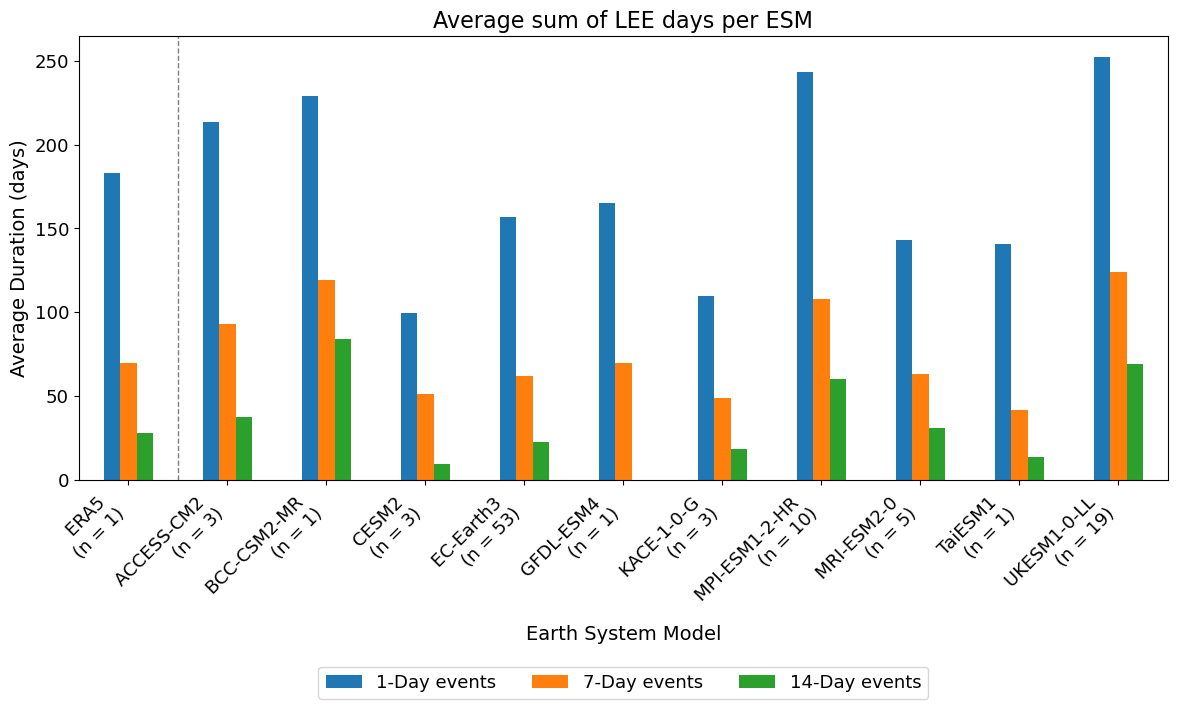

In [57]:
# make text a bit larger globally (adjust values as you like)
plt.rcParams.update({
    'font.size': 14,            # base font size
    'axes.titlesize': 16,       # title
    'axes.labelsize': 14,       # x/y labels
    'xtick.labelsize': 13,      # x tick labels
    'ytick.labelsize': 13,      # y tick labels
    'legend.fontsize': 13       # legend text
})

# pick the 3 columns we want
df = LEE_all_comp.set_index('ESM_label')[['LEE_vl_dur_avg', 'LEE_7_dur_avg', 'LEE_14_dur_avg']].copy()

# find ERA5 label (works if label contains extra text like "ERA5\n(n = 1)")
era_label = next((lab for lab in df.index if 'ERA5' in lab), None)

# reorder so ERA5 is first, then the rest (no blank rows)
new_index = [era_label] + [lab for lab in df.index if lab != era_label]
df_reordered = df.loc[new_index]

# plot grouped bars
ax = df_reordered.plot(kind='bar', figsize=(12, 8))

# draw a dashed vertical line between ERA5 and the rest
era_pos = new_index.index(era_label)  # should be 0, but computed generally
# place line halfway between ERA5 group and the next group
x_line = era_pos + 0.5
ax.axvline(x=x_line, color="#7E7E7E", linestyle='--', linewidth=1, label='_nolegend_')

# cosmetics
legend = ['1-Day events', '7-Day events', '14-Day events']
ax.set_title('Average sum of LEE days per ESM')
ax.legend(legend, loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=3)
ax.set_ylabel('Average Duration (days)')
ax.set_xlabel('Earth System Model')
ax.set_xticklabels(df_reordered.index, rotation=45, ha='right')
plt.tight_layout()

plt.savefig('/home/onennecke/Code/Figures/LEE_durations_comparison.png', dpi=300)

plt.show()


----

## Calculation of SRLI (OLD)

In [ ]:
import xarray as xr
import dask.array as da
import numpy as np
from scipy.stats import norm

def compute_srli(data_array, eps=1e-4): #1/(2*180180)
    """
    Compute the SRLI (Standardised Residual Load Index) over the full dataset,
    while keeping the shape and metadata of the input xarray DataArray.

    Parameters:
    - data_array (xarray.DataArray): input residual load (shape: ESM_run x time)

    Returns:
    - srli (xarray.DataArray): same shape as input, with SRLI values
    """
    # Compute ECDF ranks using Dask
    def ecdf_rank(values):
        # Sort the values
        sorted_vals = np.sort(values)
        # Use searchsorted to get the ECDF
        ranks = np.searchsorted(sorted_vals, values, side="right")
        ecdf_vals = (ranks + 1) / (len(values) + 1)
        return np.clip(ecdf_vals, eps, 1 - eps)  # avoid 0 and 1
    
    
    # Compute ECDF on full dataset (across all dimensions)
    ecdf = data_array.copy(data=da.map_blocks(
        lambda block: ecdf_rank(block.flatten()).reshape(block.shape),
        data_array.data,
        dtype=float
    ))

    # Apply inverse normal CDF (probit function)
    srli = xr.apply_ufunc(
        norm.ppf,
        ecdf,
        dask='parallelized',
        output_dtypes=[float]
    )

    # Rename the result
    srli.name = "SRLI"

    return srli


In [89]:
srli_tst = compute_srli(RL)

In [ ]:
# Time series of "True" when threshold is exceeded, "False" otherwise

exceed_bool = xr.where(srli_tst.values > 1.64, True, False)

# Find contiguous regions of exceed_bool = True
events, n_events = ndimage.label(exceed_bool)

In [74]:
events

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)

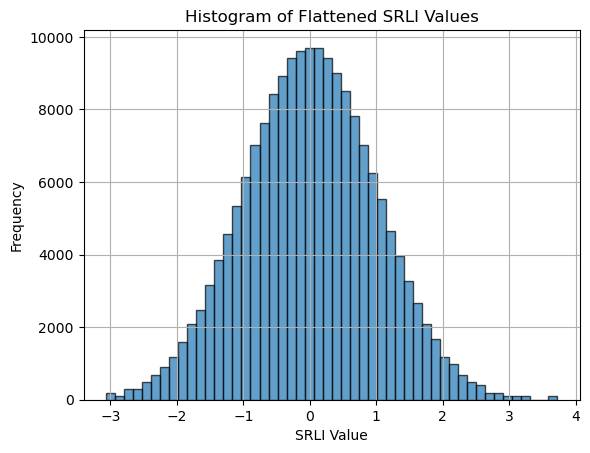

In [90]:
import matplotlib.pyplot as plt

# Flatten the SRLI values and create a histogram
plt.hist(srli_tst.values.flatten(), bins=50, edgecolor='k', alpha=0.7)
plt.xlabel('SRLI Value')
plt.ylabel('Frequency')
plt.title('Histogram of Flattened SRLI Values')
plt.grid(True)
plt.show()

## Old Code

#### SRLI for individual run

In [ ]:
import numpy as np
from scipy.stats import norm

def calculate_srli(residual_load_series):
    """
    Calculate the Standardised Residual Load Index (SRLI) from a series of residual load values.
    
    Parameters:
    - residual_load_series: pd.Series or np.array of residual load values

    Returns:
    - srli_values: np.array of SRLI values
    """
    # Ensure data is a numpy array
    data = np.array(residual_load_series)
    
    # Rank the data to calculate the empirical CDF
    sorted_data = np.sort(data)
    ranks = np.searchsorted(sorted_data, data, side='right')
    empirical_cdf = (ranks + 1) / (len(data) + 1)

    # Apply the inverse of the standard normal CDF (probit)
    srli_values = norm.ppf(empirical_cdf)
    
    return srli_values